# Procesamiento_EDA_muestra

El objetivo de este código es procesar y visualizar la muestra de audios de DAIC-WOZ de acuerdo a lo descrito en el trabajo asociado, con la finalidad de poder extraer posteriormente features acústicas y explotarse en modelos predictivos

## 0. Setup
---

In [1]:
import os
import glob

import pandas as pd
import numpy as np
import librosa

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
# Path con dataset
path_sample = r'D:/DAIZ-WOZ/base/'

# Archivos
path_labels_train = os.path.join(path_sample, 'Docs/train_split_Depression_AVEC2017.csv')
path_labels_dev = os.path.join(path_sample, 'Docs/dev_split_Depression_AVEC2017.csv')
path_labels_test = os.path.join(path_sample, 'Docs/full_test_split.csv')

# Speakers entrevista
name_paciente = 'Participant'
name_entrevistador = 'Ellie'

## 1. Muestra en crudo
---

### 1.1 Carga

In [3]:
# Carga dfs train/dev
df_train = pd.read_csv(path_labels_train)
df_train['split'] = 'train'

df_dev   = pd.read_csv(path_labels_dev)
df_dev['split'] = 'dev'

# Concat de ambos
df_full = pd.concat([df_train, df_dev], ignore_index=True)
df_full

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving,split
0,303,0,0,0,0,0,0.0,0,0,0,0,0,train
1,304,0,6,0,0,1,1.0,2,2,0,0,0,train
2,305,0,7,1,0,1,1.0,2,2,1,0,0,train
3,310,0,4,1,1,1,0.0,0,0,1,1,0,train
4,312,0,2,1,0,0,1.0,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,483,1,15,1,0,1,3.0,3,3,2,3,0,dev
138,484,0,9,0,1,1,0.0,3,1,2,1,0,dev
139,489,0,3,1,0,1,2.0,0,0,0,0,0,dev
140,490,0,2,1,0,1,0.0,1,0,0,0,0,dev


In [4]:
# Se filtran columnas de interés y se añade split de test
df_full = df_full[['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'split']]

df_test = pd.read_csv(path_labels_test)
df_test['split'] = 'test'
df_test = df_test.rename(
    columns={
        'PHQ_Binary': 'PHQ8_Binary',
        'PHQ_Score': 'PHQ8_Score'
    }
)

df_full = pd.concat([df_full, df_test], ignore_index=True)

# Formateo columnas
df_full.columns = df_full.columns.str.strip().str.lower()
df_full = df_full.sort_values(by='participant_id').reset_index(drop=True)
df_full

,participant_id,phq8_binary,phq8_score,gender,split
0,300,0,2,1,test
1,301,0,3,1,test
2,302,0,4,1,dev
3,303,0,0,0,train
4,304,0,6,0,train
...,...,...,...,...,...
184,488,0,0,0,train
185,489,0,3,1,dev
186,490,0,2,1,dev
187,491,0,8,0,train


### 1.2 Cálculo de variables

In [5]:
# Path con el audio
df_full['path_audio'] = [path_sample + str(N) + '_P/' + str(N) + '_AUDIO.wav' for N in df_full['participant_id'].values]

# Path con la transcripción
df_full['path_transcript'] = [path_sample + str(N) + '_P/' + str(N) + '_TRANSCRIPT.csv' for N in df_full['participant_id'].values]
df_full

,participant_id,phq8_binary,phq8_score,gender,split,path_audio,path_transcript
0,300,0,2,1,test,D:/DAIZ-WOZ/base/300_P/300_AUDIO.wav,D:/DAIZ-WOZ/base/300_P/300_TRANSCRIPT.csv
1,301,0,3,1,test,D:/DAIZ-WOZ/base/301_P/301_AUDIO.wav,D:/DAIZ-WOZ/base/301_P/301_TRANSCRIPT.csv
2,302,0,4,1,dev,D:/DAIZ-WOZ/base/302_P/302_AUDIO.wav,D:/DAIZ-WOZ/base/302_P/302_TRANSCRIPT.csv
3,303,0,0,0,train,D:/DAIZ-WOZ/base/303_P/303_AUDIO.wav,D:/DAIZ-WOZ/base/303_P/303_TRANSCRIPT.csv
4,304,0,6,0,train,D:/DAIZ-WOZ/base/304_P/304_AUDIO.wav,D:/DAIZ-WOZ/base/304_P/304_TRANSCRIPT.csv
...,...,...,...,...,...,...,...
184,488,0,0,0,train,D:/DAIZ-WOZ/base/488_P/488_AUDIO.wav,D:/DAIZ-WOZ/base/488_P/488_TRANSCRIPT.csv
185,489,0,3,1,dev,D:/DAIZ-WOZ/base/489_P/489_AUDIO.wav,D:/DAIZ-WOZ/base/489_P/489_TRANSCRIPT.csv
186,490,0,2,1,dev,D:/DAIZ-WOZ/base/490_P/490_AUDIO.wav,D:/DAIZ-WOZ/base/490_P/490_TRANSCRIPT.csv
187,491,0,8,0,train,D:/DAIZ-WOZ/base/491_P/491_AUDIO.wav,D:/DAIZ-WOZ/base/491_P/491_TRANSCRIPT.csv


Se eliminan las 3 sesiones sin información del asistente en sus transcripciones: **451, 458, 480**

In [6]:
sesiones_noInfo = [451, 458, 480]

df_filt = df_full[~df_full['participant_id'].isin(sesiones_noInfo)]

n_eliminadas = len(df_full) - len(df_filt)
pct_eliminadas = n_eliminadas / len(df_full) * 100

print(f'Eliminadas {n_eliminadas} sesiones ({pct_eliminadas:.1f}% de la muestra)')

Eliminadas 3 sesiones (1.6% de la muestra)


Una vez filtrado el dataset, se calculan variables para realizar un EDA preliminar pre procesamiento. Las variables son:

* <u>Archivo de audio</u>
* **Duración del audio**: duración del archivo de audio en minutos

* <u>Transcripciones</u>
    * <u>Tiempo hablado</u>
        * **Duración de la entrevista**: tiempo entre el comienzo de la primera intervención y el final de la última
        * **Número de turnos por participante**: número de veces en que cada participante habla
        * **Tiempo total hablado por participante**: suma de duración de los turnos
        * **Media de tiempo hablado por participante**: media de tiempo de duración de los turnos
        * **Desviación estandar de tiempo hablado por participante**: desviación estándar de tiempo de duración de los turnos
        * **Ratio de habla respecto de total**: porcentaje de habla de cada participante respecto del tiempo total (pausa + turno/hablado)
    * <u>Pausas interturno</u>
        * **Tiempo total de pausas**: silencio entre turnos (pausas del paciente, latencia del entrevistador...)
        * **Media de tiempo total de pausas**: media de tiempo de silencio entre turnos
        * **Desviación estándar de tiempo total de pausas**: desviación estándar de tiempo de silencio entre turnos
        * **Ratio de pausa respecto del total hablado**: porcentaje de pausa respecto del tiempo total (pausa + turno/hablado)

In [7]:
def get_audio_duration_min(path_audio):
    """
    UDF: devuelve duración en minutos de audio dada su ruta
    """

    if not isinstance(path_audio, str) or not os.path.exists(path_audio):
        return np.nan
    
    try:
        return librosa.get_duration(path=path_audio) / 60
    
    except Exception:
        return np.nan


def get_transcript_stats(transcript_path):
    """
    UDF: calcula métricas de tiempo de habla y pausas a partir del
    csv de transcript del DAIC-WOZ
    """

    # Variables a calcular
    cols = [
        # Tiempo hablado - Total
        'durSession',

        # Paciente
            # Tiempo hablado
        'nTurns_pat',
        'sumSpeech_pat',
        'avgSpeech_pat',
        'stdSpeech_pat',
        'ratioSpeech_pat',
            # Pausas
        'sumPause_pat',
        'avgPause_pat',
        'stdPause_pat',
        'ratioPause_pat',

        # Asistente
            # Tiempo hablado
        'nTurns_asist',
        'sumSpeech_asist',
        'avgSpeech_asist',
        'stdSpeech_asist',
        'ratioSpeech_asist',
            # Pausas
        'sumPause_asist',
        'avgPause_asist',
        'stdPause_asist',
        'ratioPause_asist'
    ]

    empty = pd.Series({c: np.nan for c in cols})

    if not isinstance(transcript_path, str) or not os.path.exists(transcript_path):
        return empty

    try:
        df = pd.read_csv(transcript_path, sep='\t')
        df.columns = df.columns.str.strip()

        df = df.sort_values('start_time').reset_index(drop=True)
        df['duration'] = (df['stop_time'] - df['start_time']) / 60

        # Duración total de sesión
        session_duration = (
            df['stop_time'].iloc[-1] - df['start_time'].iloc[0]
        ) / 60

        # Métricas de habla por speaker
        def speaker_stats(speaker_label):
            turns = df[df['speaker'] == speaker_label]['duration']
            total = turns.sum()

            return [
                len(turns),
                total,
                turns.mean() if len(turns) > 0 else np.nan,
                turns.std() if len(turns) > 1 else np.nan,
                total / session_duration if session_duration > 0 else np.nan,
            ]

        stats_pat = speaker_stats(name_paciente)
        stats_asist = speaker_stats(name_entrevistador)

        # Métricas de pausas
        # Solo se consideran pares de speakers distintos y gaps positivos
        pause_pat = []      # Ellie -> Paciente
        pause_asist = []    # Paciente -> Ellie

        for i in range(len(df) - 1):
            curr = df.iloc[i]
            nxt = df.iloc[i + 1]

            gap = (nxt['start_time'] - curr['stop_time']) / 60

            if gap <= 0:
                continue

            if (
                curr['speaker'] == name_entrevistador
                and nxt['speaker'] == name_paciente
            ):
                pause_pat.append(gap)

            elif (
                curr['speaker'] == name_paciente
                and nxt['speaker'] == name_entrevistador
            ):
                pause_asist.append(gap)
                

        sum_pause_pat = sum(pause_pat)
        sum_pause_asist = sum(pause_asist)

        avg_pause_pat = (
            np.mean(pause_pat)
            if len(pause_pat) > 0
            else np.nan
        )

        std_pause_pat = (
            np.std(pause_pat, ddof=1)
            if len(pause_pat) > 1
            else np.nan
        )

        avg_pause_asist = (
            np.mean(pause_asist)
            if len(pause_asist) > 0
            else np.nan
        )

        std_pause_asist = (
            np.std(pause_asist, ddof=1)
            if len(pause_asist) > 1
            else np.nan
        )

        return pd.Series({
            'durSession': session_duration,

            'nTurns_pat': stats_pat[0],
            'sumSpeech_pat': stats_pat[1],
            'avgSpeech_pat': stats_pat[2],
            'stdSpeech_pat': stats_pat[3],
            'ratioSpeech_pat': stats_pat[4],

            'sumPause_pat': sum_pause_pat,
            'avgPause_pat': avg_pause_pat,
            'stdPause_pat': std_pause_pat,
            'ratioPause_pat': (
                sum_pause_pat / session_duration
                if session_duration > 0 else np.nan
            ),

            'nTurns_asist': stats_asist[0],
            'sumSpeech_asist': stats_asist[1],
            'avgSpeech_asist': stats_asist[2],
            'stdSpeech_asist': stats_asist[3],
            'ratioSpeech_asist': stats_asist[4],

            'sumPause_asist': sum_pause_asist,
            'avgPause_asist': avg_pause_asist,
            'stdPause_asist': std_pause_asist,
            'ratioPause_asist': (
                sum_pause_asist / session_duration
                if session_duration > 0 else np.nan
            )
        })

    except Exception as e:
        print(f'Error procesando {transcript_path}: {e}')
        return empty

In [8]:
df_filt['duration_audio'] = df_filt['path_audio'].apply(get_audio_duration_min)
df_filt = df_filt.join(df_filt['path_transcript'].apply(get_transcript_stats))

df_filt

c:\Users\tblxa\Desktop\Master\UNIR_IA_TFE\unir_tfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\tblxa\AppData\Local\Temp\ipykernel_4916\3798672598.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt['duration_audio'] = df_filt['path_audio'].apply(get_audio_duration_min)


,participant_id,phq8_binary,phq8_score,gender,split,path_audio,path_transcript,duration_audio,durSession,nTurns_pat,...,ratioPause_pat,nTurns_asist,sumSpeech_asist,avgSpeech_asist,stdSpeech_asist,ratioSpeech_asist,sumPause_asist,avgPause_asist,stdPause_asist,ratioPause_asist
0,300,0,2,1,test,D:/DAIZ-WOZ/base/300_P/300_AUDIO.wav,D:/DAIZ-WOZ/base/300_P/300_TRANSCRIPT.csv,10.808333,9.744667,87.0,...,0.160276,87.0,2.347333,0.026981,0.015360,0.240884,1.751000,0.030719,0.021407,0.179688
1,301,0,3,1,test,D:/DAIZ-WOZ/base/301_P/301_AUDIO.wav,D:/DAIZ-WOZ/base/301_P/301_TRANSCRIPT.csv,13.731667,12.906667,104.0,...,0.047869,77.0,1.632500,0.021201,0.021970,0.126485,1.007833,0.024581,0.018609,0.078086
2,302,0,4,1,dev,D:/DAIZ-WOZ/base/302_P/302_AUDIO.wav,D:/DAIZ-WOZ/base/302_P/302_TRANSCRIPT.csv,12.646667,11.282833,97.0,...,0.142277,89.0,1.889883,0.021235,0.020190,0.167501,1.863117,0.038815,0.019531,0.165128
3,303,0,0,0,train,D:/DAIZ-WOZ/base/303_P/303_AUDIO.wav,D:/DAIZ-WOZ/base/303_P/303_TRANSCRIPT.csv,16.421667,15.568333,103.0,...,0.052521,88.0,2.470500,0.028074,0.039247,0.158688,0.617500,0.015833,0.014834,0.039664
4,304,0,6,0,train,D:/DAIZ-WOZ/base/304_P/304_AUDIO.wav,D:/DAIZ-WOZ/base/304_P/304_TRANSCRIPT.csv,13.210000,12.000667,104.0,...,0.076774,100.0,2.735000,0.027350,0.025109,0.227904,1.061833,0.017997,0.016220,0.088481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,488,0,0,0,train,D:/DAIZ-WOZ/base/488_P/488_AUDIO.wav,D:/DAIZ-WOZ/base/488_P/488_TRANSCRIPT.csv,14.748333,14.257100,138.0,...,0.048406,64.0,2.253783,0.035215,0.050347,0.158081,1.625583,0.042779,0.086543,0.114019
185,489,0,3,1,dev,D:/DAIZ-WOZ/base/489_P/489_AUDIO.wav,D:/DAIZ-WOZ/base/489_P/489_TRANSCRIPT.csv,11.745000,10.990000,117.0,...,0.188661,85.0,2.720983,0.032012,0.045056,0.247587,1.744150,0.029069,0.029494,0.158703
186,490,0,2,1,dev,D:/DAIZ-WOZ/base/490_P/490_AUDIO.wav,D:/DAIZ-WOZ/base/490_P/490_TRANSCRIPT.csv,11.521667,11.066050,97.0,...,0.163761,77.0,2.498617,0.032450,0.042647,0.225791,1.690817,0.033153,0.029148,0.152793
187,491,0,8,0,train,D:/DAIZ-WOZ/base/491_P/491_AUDIO.wav,D:/DAIZ-WOZ/base/491_P/491_TRANSCRIPT.csv,14.695000,13.519000,146.0,...,0.038362,85.0,2.719267,0.031991,0.044806,0.201144,1.399117,0.026906,0.027475,0.103493


### 1.3 Visualización

In [9]:
sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE_WIDE = (14, 4)
FIGSIZE_SQ   = (12, 8)
 
PAT_VARS = [
    ("nTurns_pat",      "Número de turnos"),
    ("sumSpeech_pat",   "Tiempo total hablado (min)"),
    ("avgSpeech_pat",   "Duración media de turno (min)"),
    ("stdSpeech_pat",   "Desv. est. duración turno (min)"),
    ("ratioSpeech_pat", "Ratio de habla (%)"),
    
    ("sumPause_pat",    "Tiempo total de pausas (min)"),
    ("avgPause_pat",    "Media de tiempo total de pausas (min)"),
    ("stdPause_pat",    "Desv. est. de tiempo total de pausas (min)"),
    ("ratioPause_pat",  "Ratio de pausas (%)")
]
 
 
# ── 1. Distribución del PHQ-8 ──────────────────────────────────────────────────
def plot_phq8distribution_by_split(df):
    """
    Histograma del PHQ-8 con separación train/dev.
    Primera pregunta: ¿cómo es el target y está balanceado?
    """
    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
 
    # Global
    axes[0].hist(df["phq8_score"], bins=15, color="#2E86AB",
                 edgecolor="white", linewidth=0.5)
    axes[0].axvline(10, color="red", linestyle="--", linewidth=1.2,
                    label="Umbral clínico (PHQ-8 ≥ 10)")
    axes[0].set_title("Distribución PHQ-8 — Total", fontweight="bold")
    axes[0].set_xlabel("PHQ-8 score")
    axes[0].set_ylabel("Número de sesiones")
    axes[0].legend(fontsize=9)
 
    # Por split
    for split, color in [("train", "#2E86AB"), ("dev", "#37CE5DB3"), ("test", "#E84855")]:
        subset = df[df["split"] == split]["phq8_score"]
        axes[1].hist(subset, bins=15, alpha=0.6, color=color,
                     edgecolor="white", linewidth=0.5, label=split)
 
    axes[1].axvline(10, color="red", linestyle="--", linewidth=1.2,
                    label="Umbral clínico (PHQ-8 ≥ 10)")
    axes[1].set_title("Distribución PHQ-8 — Train vs Dev vs Test", fontweight="bold")
    axes[1].set_xlabel("PHQ-8 score")
    axes[1].set_ylabel("Número de sesiones")
    axes[1].legend(fontsize=9)
 
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
 
    plt.suptitle("Distribución del target (PHQ-8)", fontsize=13,
                 fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
 
    # Stats rápidas
    print("── PHQ-8 stats ──")
    print(df.groupby("split")["phq8_score"].describe().round(2))
    severos = (df["phq8_score"] >= 10).sum()
    print(f"\nSesiones con PHQ-8 ≥ 10 (umbral clínico): {severos} / {len(df)} "
          f"({severos/len(df)*100:.1f}%)")
 
 
# ── 2. Variables del paciente vs PHQ-8 ────────────────────────────────────────
def plot_vars_vs_phq8(df):
    """
    Scatter plots de cada variable del paciente contra PHQ-8.
    Pregunta: ¿hay relación visible entre habla/pausas y severidad?
    """
    n = len(PAT_VARS)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
 
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.5, nrows * 3.2))
    axes = axes.flatten()
 
    for i, (col, label) in enumerate(PAT_VARS):
        if col not in df.columns:
            axes[i].set_visible(False)
            continue
 
        axes[i].scatter(df["phq8_score"], df[col],
                        alpha=0.5, s=25, color="#2E86AB", edgecolors="none")
 
        # Línea de tendencia
        mask = df[col].notna() & df["phq8_score"].notna()
        if mask.sum() > 2:
            z = np.polyfit(df.loc[mask, "phq8_score"], df.loc[mask, col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df["phq8_score"].min(), df["phq8_score"].max(), 100)
            axes[i].plot(x_line, p(x_line), color="#E84855",
                         linewidth=1.5, linestyle="--")
 
            # Correlación de Pearson
            r = df.loc[mask, ["phq8_score", col]].corr().iloc[0, 1]
            axes[i].set_title(f"{label}\nr = {r:.2f}", fontsize=9, fontweight="bold")
        else:
            axes[i].set_title(label, fontsize=9, fontweight="bold")
 
        axes[i].set_xlabel("PHQ-8 score", fontsize=8)
        axes[i].spines[["top", "right"]].set_visible(False)
 
    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle("Variables del paciente vs PHQ-8", fontsize=13,
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
 
 
# ── 3. Boxplots por grupo de severidad ────────────────────────────────────────
def plot_boxplots_by_severity(df):
    """
    Boxplots de cada variable del paciente agrupados por severidad depresiva.
    Pregunta: ¿se separan bien los grupos?
    """
    df = df.copy()
    df["severity"] = pd.cut(
        df["phq8_score"],
        bins=[-1, 4, 9, 14, 24],
        labels=["Mínima\n(0-4)", "Leve\n(5-9)", "Moderada\n(10-14)", "Severa\n(15+)"]
    )
 
    n = len(PAT_VARS)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
 
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten()
 
    palette = ["#8ecae6", "#219ebc", "#fb8500", "#e63946"]
 
    for i, (col, label) in enumerate(PAT_VARS):
        if col not in df.columns:
            axes[i].set_visible(False)
            continue
 
        sns.boxplot(data=df, x="severity", y=col,
                    palette=palette, ax=axes[i],
                    linewidth=0.8, fliersize=3)
 
        axes[i].set_title(label, fontsize=9, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].tick_params(axis='x', labelsize=8)
        axes[i].spines[["top", "right"]].set_visible(False)
 
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle("Variables del paciente por grupo de severidad (PHQ-8)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
 
 
# ── 4.1 Comparación variables por split ───────────────────────────────────────────────
def plot_vars_by_split(df):
    """
    Distribución de las variables del paciente por split.
    Pregunta: ¿son train y dev (y test si existe) comparables?
    Los bins se calculan sobre el rango global de cada variable para que
    sean comparables entre splits (mismo ancho de barra en todos).
    """
    splits_colors = [("train", "#2E86AB"), ("dev", "#37CE5D"), ("test", "#E848556E")]
    splits_presentes = [s for s, _ in splits_colors if s in df["split"].unique()]
 
    n = len(PAT_VARS)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
 
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.5, nrows * 3.2))
    axes = axes.flatten()
 
    for i, (col, label) in enumerate(PAT_VARS):
        if col not in df.columns:
            axes[i].set_visible(False)
            continue
 
        # Bins comunes sobre el rango global de la columna
        col_min = df[col].min()
        col_max = df[col].max()
        bins = np.linspace(col_min, col_max, 16)  # 16 edges = 15 bins
 
        for split, color in splits_colors:
            if split not in splits_presentes:
                continue
            subset = df[df["split"] == split][col].dropna()
            axes[i].hist(subset, bins=bins, alpha=0.6, color=color,
                         edgecolor="white", linewidth=0.4, label=split,
                         density=True)
 
        axes[i].set_title(label, fontsize=9, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].legend(fontsize=7)
        axes[i].spines[["top", "right"]].set_visible(False)
 
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle("Distribución de variables por split",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ── 4.2 Comparación variables por split tipo kde ─────────────────────────────────────────
def plot_vars_by_split_kde(df):
    """
    Distribución de las variables del paciente por split usando KDE.
    Evita el problema de transparencias solapadas en histogramas múltiples.
    """
    splits_colors = [("train", "#2E86AB"), ("dev", "#E84855"), ("test", "#2CA02C")]
    splits_presentes = [s for s, _ in splits_colors if s in df["split"].unique()]
 
    n = len(PAT_VARS)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
 
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.5, nrows * 3.2))
    axes = axes.flatten()
 
    for i, (col, label) in enumerate(PAT_VARS):
        if col not in df.columns:
            axes[i].set_visible(False)
            continue
 
        for split, color in splits_colors:
            if split not in splits_presentes:
                continue
            subset = df[df["split"] == split][col].dropna()
            if len(subset) < 2:
                continue
 
            # KDE con relleno suave
            sns.kdeplot(subset, ax=axes[i], color=color, label=split,
                        linewidth=2, fill=True, alpha=0.15)
            # Contorno más marcado encima
            sns.kdeplot(subset, ax=axes[i], color=color,
                        linewidth=2, fill=False)
 
        axes[i].set_title(label, fontsize=9, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].legend(fontsize=7)
        axes[i].spines[["top", "right"]].set_visible(False)
 
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle("Distribución de variables por split",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

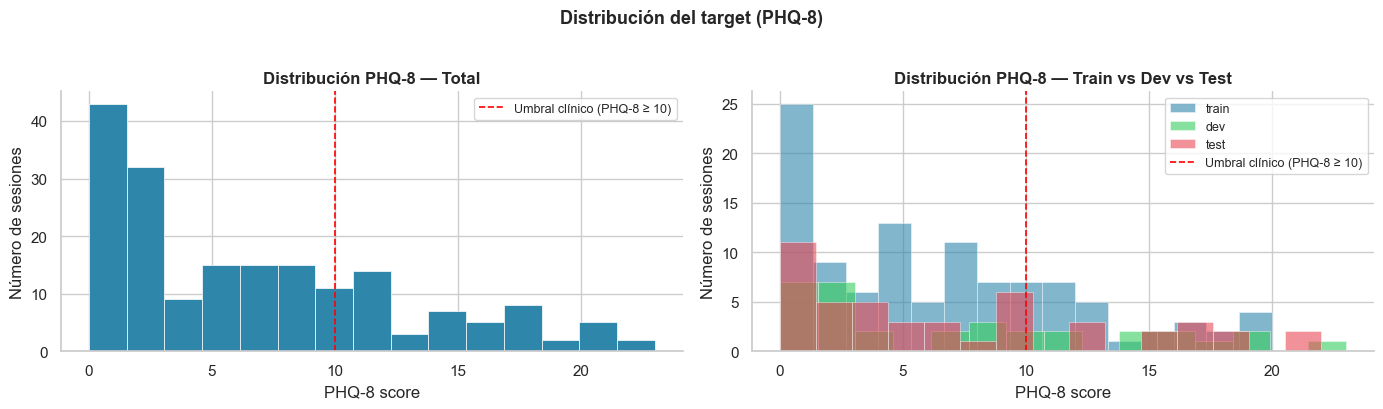

── PHQ-8 stats ──
       count  mean   std  min  25%  50%   75%   max
split                                              
dev     33.0  7.61  6.75  0.0  2.0  7.0  12.0  23.0
test    46.0  7.11  6.48  0.0  2.0  5.0  11.5  22.0
train  107.0  6.42  5.46  0.0  2.0  6.0  10.0  20.0

Sesiones con PHQ-8 ≥ 10 (umbral clínico): 57 / 186 (30.6%)


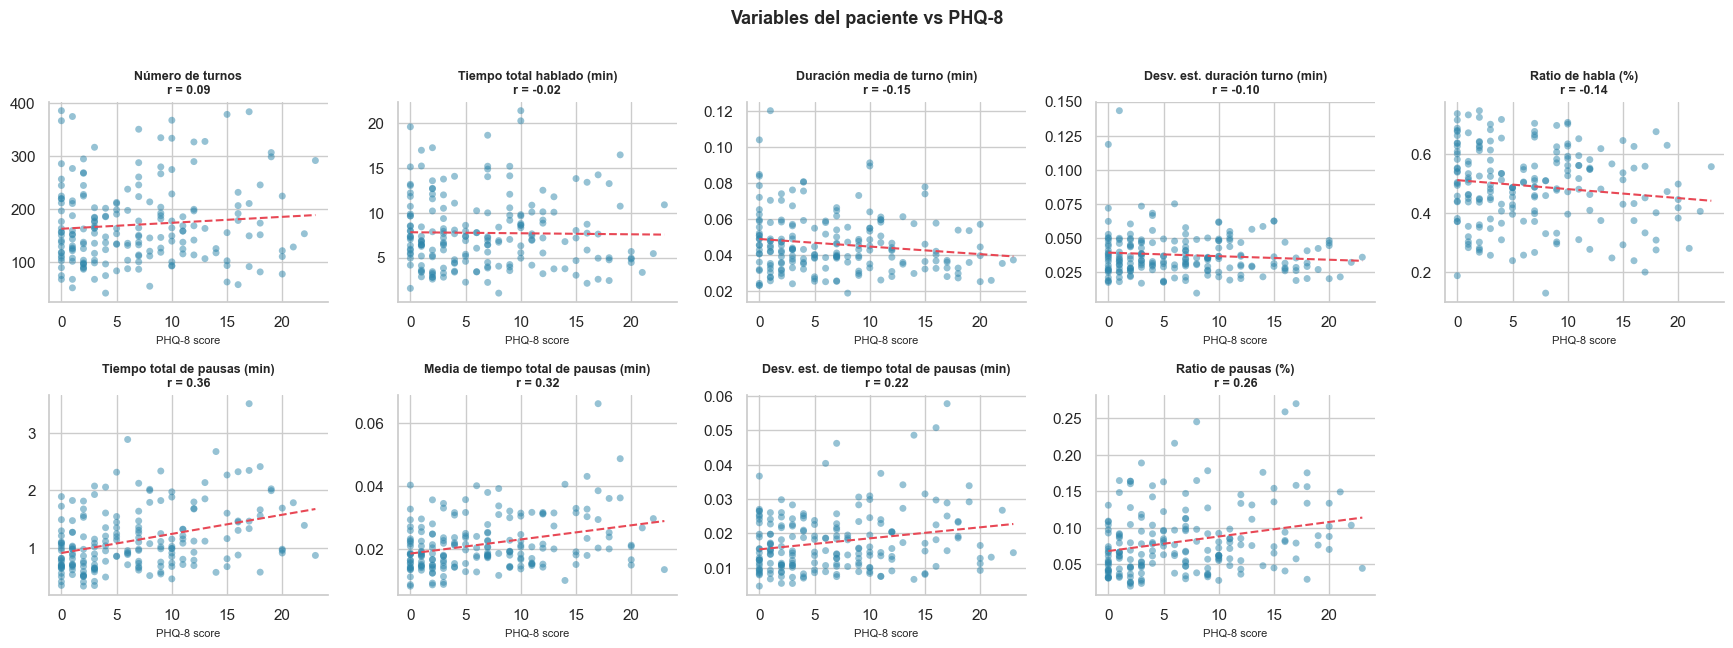

C:\Users\tblxa\AppData\Local\Temp\ipykernel_4916\2281877861.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y=col,
C:\Users\tblxa\AppData\Local\Temp\ipykernel_4916\2281877861.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y=col,
C:\Users\tblxa\AppData\Local\Temp\ipykernel_4916\2281877861.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y=col,
C:\Users\tblxa\AppData\Local\Temp\ipykernel_4916\2281877861.py:144: FutureWarning: 

Passing `palette` without assi

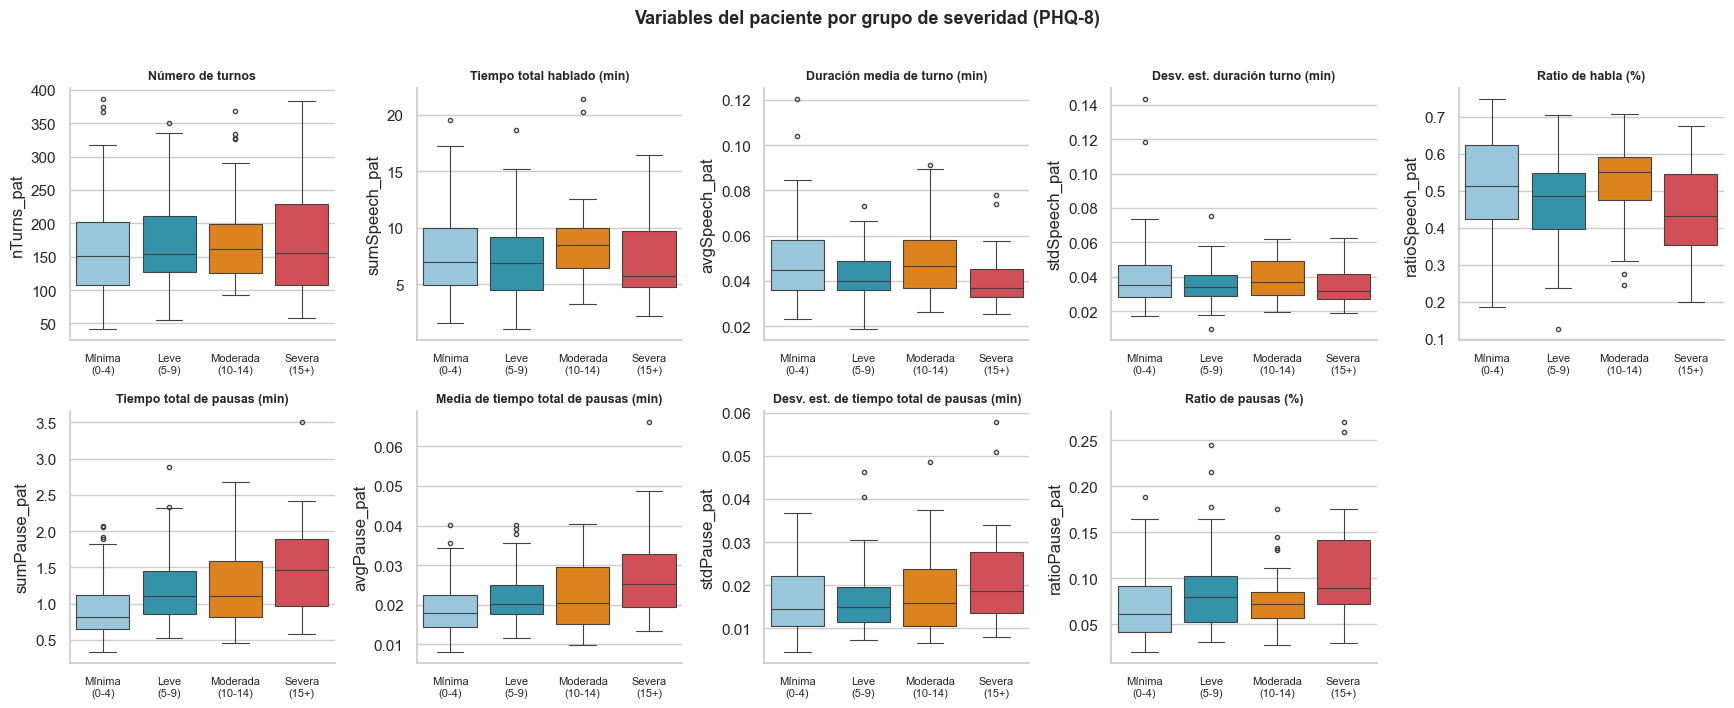

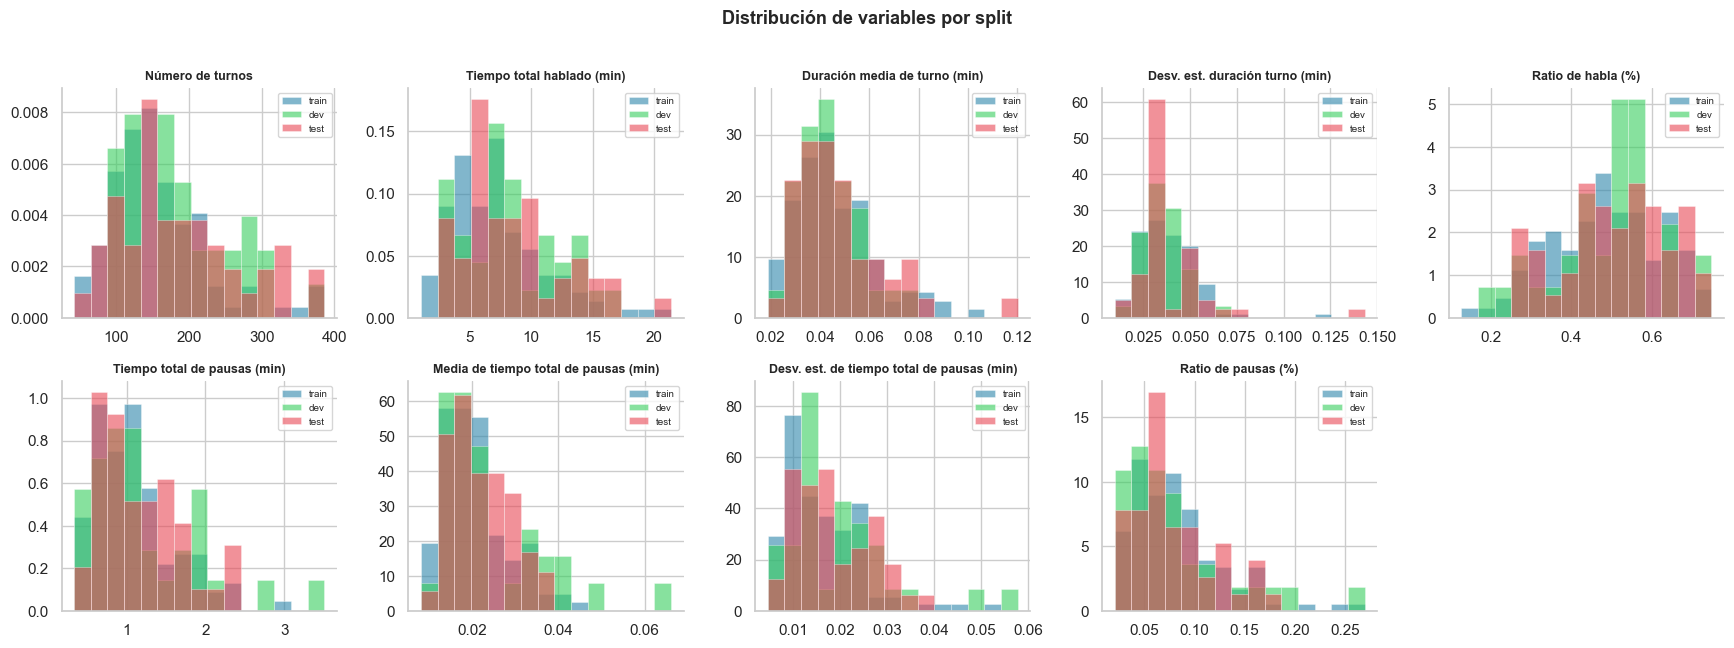

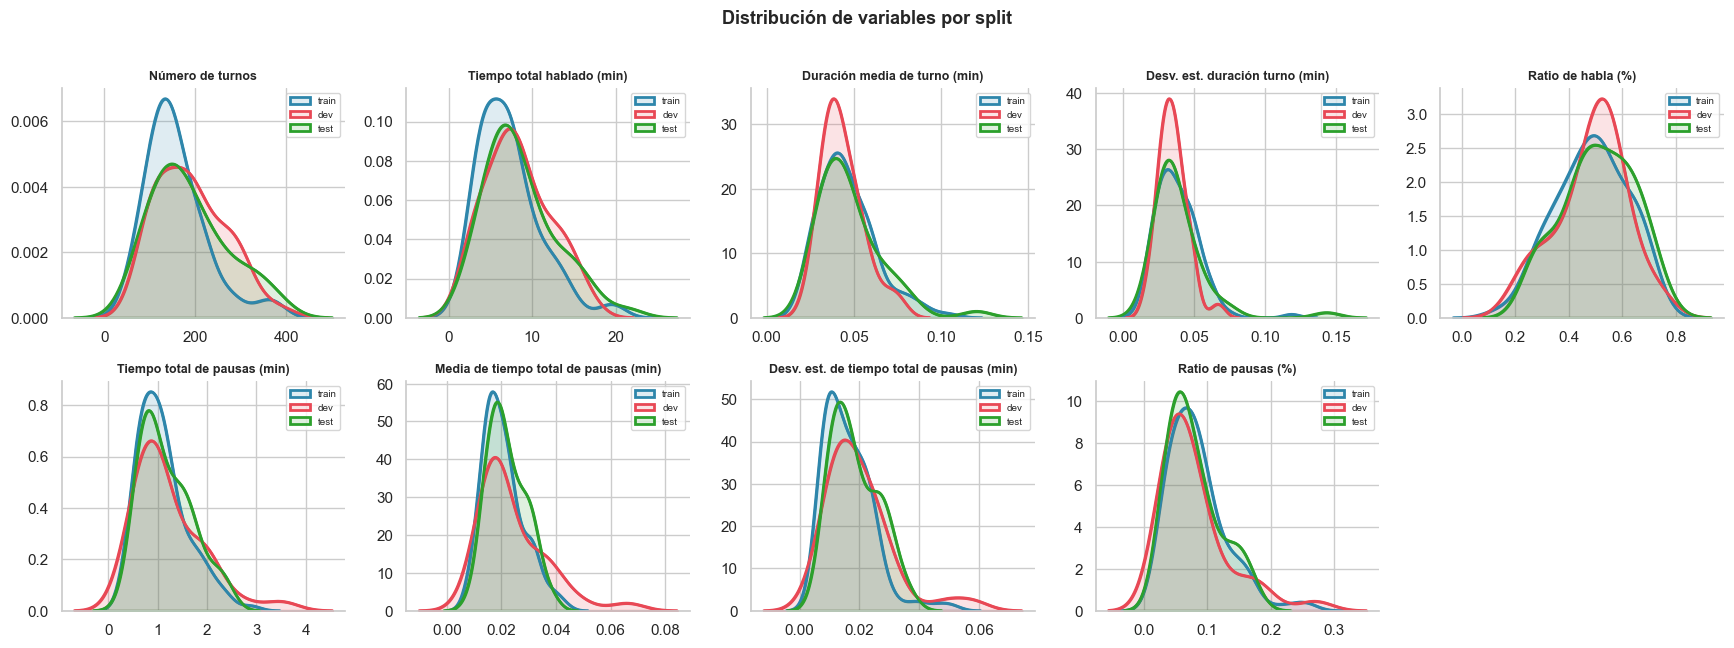

In [10]:
plot_phq8distribution_by_split(df_filt)
plot_vars_vs_phq8(df_filt)
plot_boxplots_by_severity(df_filt)
plot_vars_by_split(df_filt)
plot_vars_by_split_kde(df_filt)

## 2. Procesamiento Muestra
---

Pasos en el procesamiento:
1. Se elimina 